# Integrating Predictive Models with Operational Policies for Constrained Lead Qualification
This notebook reflects the coding for the masters dissertation.

In [47]:

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete.")



Setup complete.


In [48]:
# Loading data from google drive:
from google.colab import drive
drive.mount('/content/drive')
df_raw = pd.read_csv("/content/drive/MyDrive/Masters_Constrained_Lead_Qualification/Lead Scoring.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
# Upload "Lead Scoring.csv" to Colab, or load from Google Drive.


print(f"Shape: {df_raw.shape}")
print(f"Columns:\n{df_raw.columns.tolist()}")
print(f"\nConversion rate: {df_raw['Converted'].mean():.4f}")
df_raw.head()

Shape: (9240, 37)
Columns:
['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']

Conversion rate: 0.3854


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [50]:
# =============================================================================
# CELL 02 — PRESERVE RAW POLICY COLUMNS
#
# This must happen BEFORE any cleaning, grouping, or encoding.
# Policy rules (H1, H2, P1, P2, S1, S2, S3) are applied using these raw
# values. If you group rare categories first, values like "Referral" or
# "Email Link Clicked" may be collapsed into "Other" and break S3/S4.
# =============================================================================

POLICY_COLUMNS = [
    "Do Not Email",
    "Do Not Call",
    "TotalVisits",
    "Total Time Spent on Website",
    "Last Activity",
    "Lead Origin",
    "Lead Source",
    "What is your current occupation",
]

# Confirm all policy columns exist in the raw data
missing_policy = [c for c in POLICY_COLUMNS if c not in df_raw.columns]
if missing_policy:
    raise ValueError(f"Missing policy columns in raw data: {missing_policy}")

policy_df_full = df_raw[POLICY_COLUMNS].copy()

print("Raw policy columns preserved.")
print(f"\nDo Not Email value counts:\n{policy_df_full['Do Not Email'].value_counts(dropna=False)}")
print(f"\nDo Not Call value counts:\n{policy_df_full['Do Not Call'].value_counts(dropna=False)}")

Raw policy columns preserved.

Do Not Email value counts:
Do Not Email
No     8506
Yes     734
Name: count, dtype: int64

Do Not Call value counts:
Do Not Call
No     9238
Yes       2
Name: count, dtype: int64


In [51]:

# =============================================================================
# CELL 03 — LEAKAGE REMOVAL
#
# These columns are excluded a priori, before any data inspection of their
# predictive value. They contain post-hoc human judgments or derived scores
# that are correlated with the conversion outcome and would not be available
# at the point of real-time qualification.
# =============================================================================

LEAKAGE_COLUMNS = [
    "Tags",
    "Lead Quality",
    "Asymmetrique Activity Index",
    "Asymmetrique Profile Index",
    "Asymmetrique Activity Score",
    "Asymmetrique Profile Score",
]

ID_COLUMNS = ["Prospect ID", "Lead Number"]

cols_to_drop = [c for c in LEAKAGE_COLUMNS + ID_COLUMNS if c in df_raw.columns]
df = df_raw.drop(columns=cols_to_drop).copy()

print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Shape after leakage removal: {df.shape}")



Dropped 8 columns: ['Tags', 'Lead Quality', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score', 'Prospect ID', 'Lead Number']
Shape after leakage removal: (9240, 29)


In [52]:

# =============================================================================
# CELL 04 — CLEAN DATA
#
# Steps:
#   a. Replace "Select" placeholder with NaN (form fields left blank by user)
#   b. Remove duplicates
#   c. Handle high-missing columns
#   d. Construct derived feature: Engagement Intensity
#   e. Note: Do Not Email / Do Not Call are NOT used as model features.
#      They are kept in the dataframe here only so they survive the split
#      alongside X. Policy rules consume them from policy_df, not from X.
# =============================================================================

# a. Replace "Select" with NaN
df = df.replace("Select", np.nan)

# b. Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows.")

# c. Drop columns with >40% missing values
missing_pct = df.isnull().mean() * 100
high_missing = missing_pct[missing_pct > 40].index.tolist()
print(f"\nColumns with >40% missing (will be dropped): {high_missing}")
df = df.drop(columns=high_missing)

Removed 1687 duplicate rows.

Columns with >40% missing (will be dropped): ['How did you hear about X Education', 'Lead Profile']


In [53]:

# d. Derived feature: average depth of engagement per visit
#    Captures intensity of interest rather than raw visit volume.
#    A lead with 60 minutes across 2 visits differs from one with 60 minutes
#    across 20 visits. Computed before splitting; used as a model feature only.
df["Engagement Intensity"] = (
    df["Total Time Spent on Website"] / df["TotalVisits"].replace(0, np.nan)
)
df["Engagement Intensity"] = df["Engagement Intensity"].replace(
    [np.inf, -np.inf], np.nan
)

print(f"\nShape after cleaning: {df.shape}")
print(f"\nRemaining missing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))



Shape after cleaning: (7553, 28)

Remaining missing values (top 10):
City                                             2040
What matters most to you in choosing a course    1921
What is your current occupation                  1902
Specialization                                   1844
Country                                           779
Engagement Intensity                              644
Page Views Per Visit                              136
TotalVisits                                       136
Last Activity                                     102
Lead Source                                        23
dtype: int64


Baseline conversion rate: 0.3979



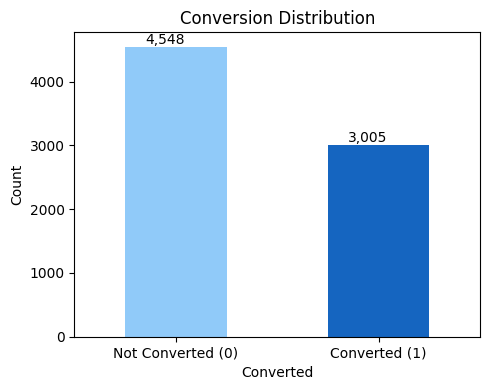

In [54]:

# =============================================================================
# CELL 05 — EDA AND POLICY JUSTIFICATION
#
# The policy rules (H1, H2, P1, P2, S1, S2, S3) are defined a priori based
# on operational logic, not derived from the data. EDA is used to describe
# and sanity-check their empirical behaviour — not to optimise them. This
# protects against the criticism that the rules were tuned to the dataset.
#
# Each chart is labelled with the rule it justifies.
# =============================================================================

BASELINE_RATE = df["Converted"].mean()
print(f"Baseline conversion rate: {BASELINE_RATE:.4f}\n")

# --- 5a. Class balance ---
fig, ax = plt.subplots(figsize=(5, 4))
df["Converted"].value_counts().plot(kind="bar", ax=ax, color=["#90CAF9", "#1565C0"])
ax.set_title("Conversion Distribution")
ax.set_xticklabels(["Not Converted (0)", "Converted (1)"], rotation=0)
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + 0.1, p.get_height() + 50))
plt.tight_layout()
plt.savefig("fig_01_class_balance.png", dpi=150)
plt.show()

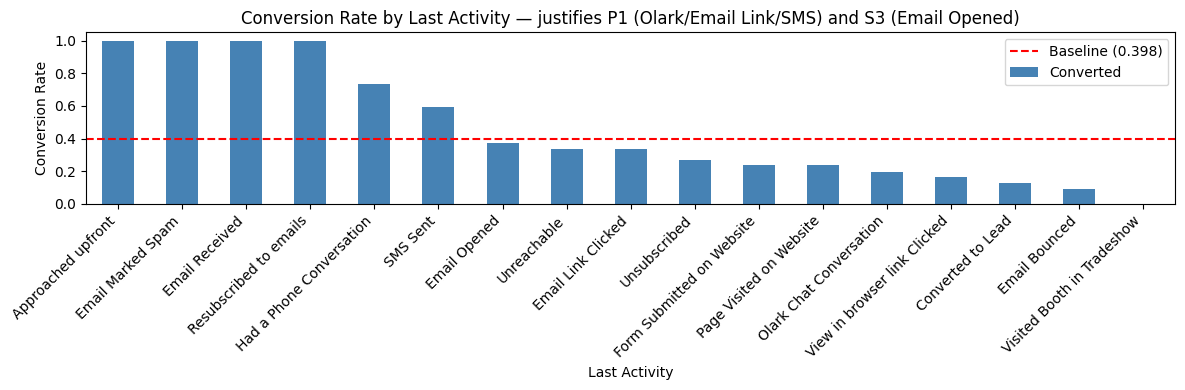

In [55]:

# --- 5b. Conversion rate by Last Activity (justifies P1, S3) ---
if "Last Activity" in df.columns:
    conv_by_activity = (
        df.groupby("Last Activity")["Converted"].mean().sort_values(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(12, 4))
    conv_by_activity.plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(BASELINE_RATE, color="red", linestyle="--", label=f"Baseline ({BASELINE_RATE:.3f})")
    ax.set_title("Conversion Rate by Last Activity — justifies P1 (Olark/Email Link/SMS) and S3 (Email Opened)")
    ax.set_ylabel("Conversion Rate")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("fig_02_conv_by_last_activity.png", dpi=150)
    plt.show()


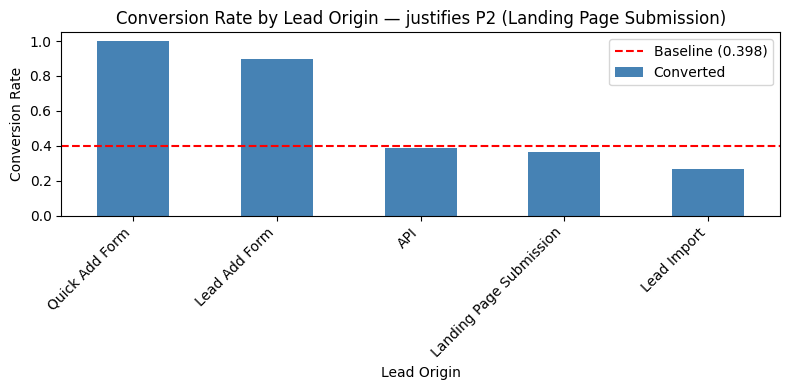

In [56]:

# --- 5c. Conversion rate by Lead Origin (justifies P2) ---
if "Lead Origin" in df.columns:
    conv_by_origin = (
        df.groupby("Lead Origin")["Converted"].mean().sort_values(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    conv_by_origin.plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(BASELINE_RATE, color="red", linestyle="--", label=f"Baseline ({BASELINE_RATE:.3f})")
    ax.set_title("Conversion Rate by Lead Origin — justifies P2 (Landing Page Submission)")
    ax.set_ylabel("Conversion Rate")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("fig_03_conv_by_lead_origin.png", dpi=150)
    plt.show()

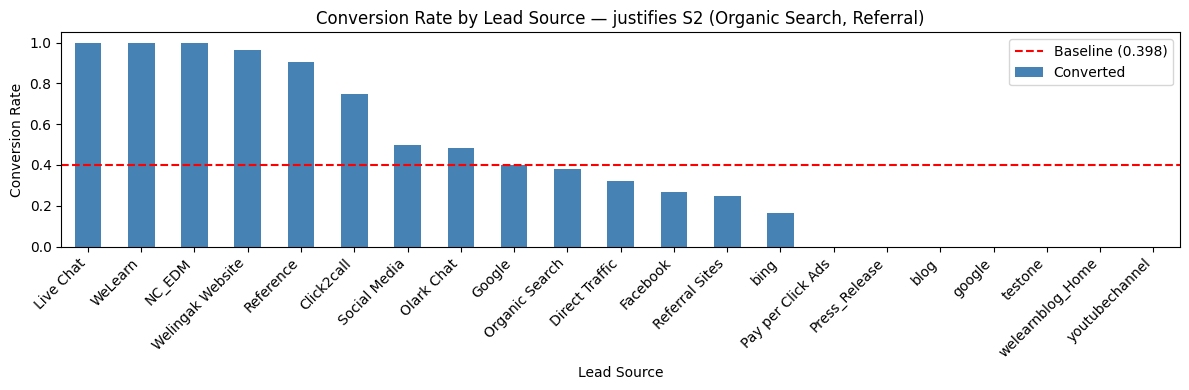

In [57]:

# --- 5d. Conversion rate by Lead Source (justifies S2) ---
if "Lead Source" in df.columns:
    conv_by_source = (
        df.groupby("Lead Source")["Converted"].mean().sort_values(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(12, 4))
    conv_by_source.plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(BASELINE_RATE, color="red", linestyle="--", label=f"Baseline ({BASELINE_RATE:.3f})")
    ax.set_title("Conversion Rate by Lead Source — justifies S2 (Organic Search, Referral)")
    ax.set_ylabel("Conversion Rate")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("fig_04_conv_by_lead_source.png", dpi=150)
    plt.show()

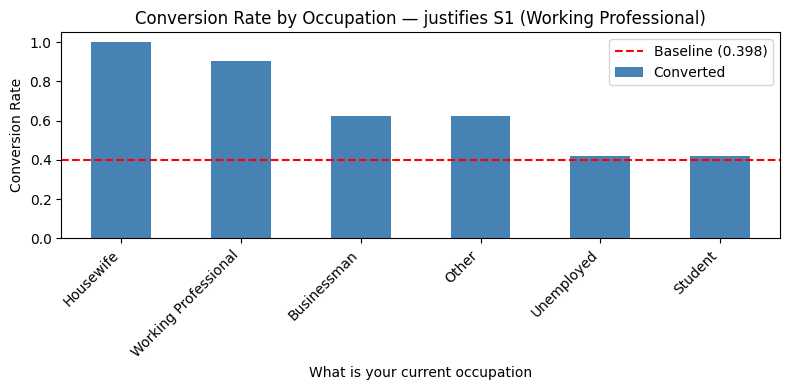

In [58]:

# --- 5e. Conversion rate by Occupation (justifies S1) ---
occ_col = "What is your current occupation"
if occ_col in df.columns:
    conv_by_occ = (
        df.groupby(occ_col)["Converted"].mean().sort_values(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    conv_by_occ.plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(BASELINE_RATE, color="red", linestyle="--", label=f"Baseline ({BASELINE_RATE:.3f})")
    ax.set_title("Conversion Rate by Occupation — justifies S1 (Working Professional)")
    ax.set_ylabel("Conversion Rate")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("fig_05_conv_by_occupation.png", dpi=150)
    plt.show()


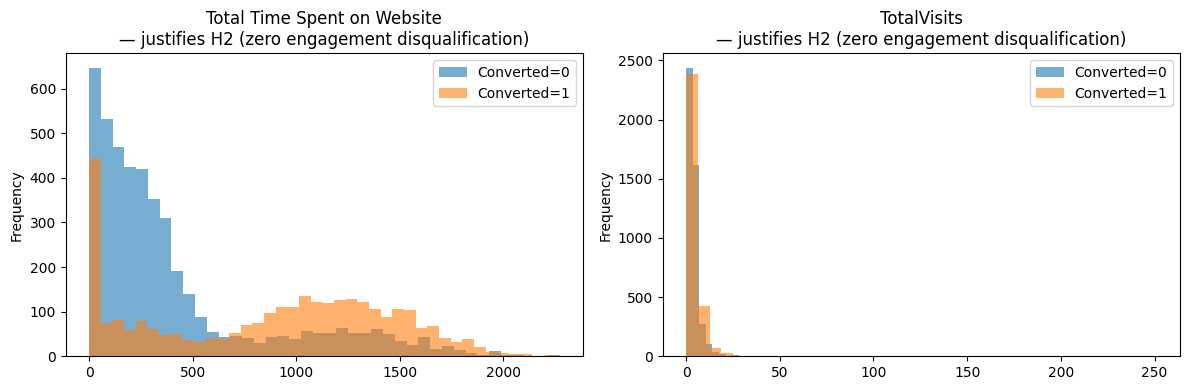

In [59]:

# --- 5f. Engagement distributions: converted vs not (justifies H2) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Total Time Spent on Website", "TotalVisits"]):
    for label, grp in df.groupby("Converted")[col]:
        grp.plot(kind="hist", bins=40, alpha=0.6, ax=ax, label=f"Converted={label}")
    ax.set_title(f"{col}\n— justifies H2 (zero engagement disqualification)")
    ax.legend()
plt.tight_layout()
plt.savefig("fig_06_engagement_distributions.png", dpi=150)
plt.show()


In [60]:

# --- 5g. Opt-out prevalence (justifies H1) ---
dne_raw = policy_df_full["Do Not Email"]
dnc_raw = policy_df_full["Do Not Call"]

dne_count = dne_raw.isin(["Yes", 1, True]).sum()
dnc_count = dnc_raw.isin(["Yes", 1, True]).sum()
both_count = (
    dne_raw.isin(["Yes", 1, True]) & dnc_raw.isin(["Yes", 1, True])
).sum()

print(f"Do Not Email flagged: {dne_count} ({dne_count/len(df)*100:.1f}%)")
print(f"Do Not Call flagged:  {dnc_count} ({dnc_count/len(df)*100:.1f}%)")
print(f"Both flagged (H1):    {both_count} ({both_count/len(df)*100:.1f}%) — these leads are disqualified")


Do Not Email flagged: 734 (9.7%)
Do Not Call flagged:  2 (0.0%)
Both flagged (H1):    0 (0.0%) — these leads are disqualified


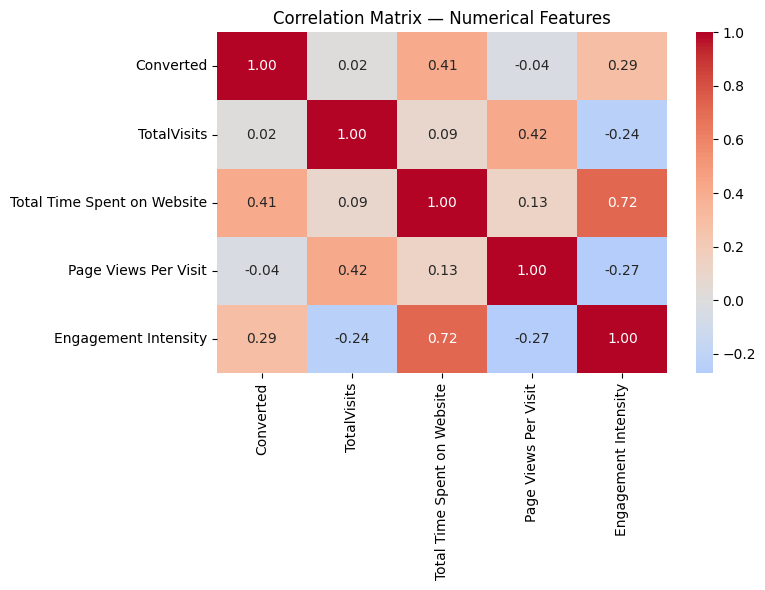

In [61]:

# --- 5h. Correlation heatmap ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.savefig("fig_07_correlation_heatmap.png", dpi=150)
plt.show()


In [62]:

# =============================================================================
# CELL 06 — TRAIN / TEST SPLIT
#
# Stratified 80/20 split preserving the conversion class distribution.
# policy_df_full is split alongside X and y to maintain index alignment.
# policy_df_full must align with df row-for-row at this point.
# =============================================================================

# Reset index after cleaning/dedup to ensure alignment
df = df.reset_index(drop=True)
policy_df_full = policy_df_full.loc[df.index].reset_index(drop=True)

TARGET = "Converted"
y = df[TARGET]
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test, policy_train, policy_test = train_test_split(
    X,
    y,
    policy_df_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train conversion rate: {y_train.mean():.4f}")
print(f"Test conversion rate:  {y_test.mean():.4f}")



Train: (6042, 27)  |  Test: (1511, 27)
Train conversion rate: 0.3979
Test conversion rate:  0.3977


In [63]:

# =============================================================================
# CELL 07 — PREPROCESSING PIPELINE
#
# The pipeline is fit ONLY on training data.
# Do Not Email and Do Not Call are excluded from model features.
# They are policy signals, not predictive inputs — including them would blur
# the boundary between the ML score and the hard constraint layer.
# =============================================================================

# Exclude policy opt-out fields from model input
MODEL_EXCLUDE = ["Do Not Email", "Do Not Call"]

X_train_model = X_train.drop(
    columns=[c for c in MODEL_EXCLUDE if c in X_train.columns]
)
X_test_model = X_test.drop(
    columns=[c for c in MODEL_EXCLUDE if c in X_test.columns]
)

In [64]:

# Identify feature types
numeric_features = X_train_model.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train_model.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")


Numeric features (4): ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Engagement Intensity']

Categorical features (21): ['Lead Origin', 'Lead Source', 'Last Activity', 'Country', 'Specialization', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'City', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']


In [65]:

# Preprocessing sub-pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

In [66]:

# =============================================================================
# CELL 08 — TRAIN MODELS
#
# Both models are trained on the same feature set with class weighting to
# address moderate class imbalance. Hyperparameter tuning uses 5-fold
# stratified cross-validation on the training set only.
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Logistic Regression ---
logit_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

logit_params = {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]}

logit_search = GridSearchCV(
    logit_pipeline,
    logit_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

logit_search.fit(X_train_model, y_train)

logit_auc = roc_auc_score(
    y_test,
    logit_search.predict_proba(X_test_model)[:, 1],
)

print(f"Logistic Regression  |  Best C: {logit_search.best_params_['model__C']}  |  Test AUC-ROC: {logit_auc:.4f}")


Logistic Regression  |  Best C: 0.1  |  Test AUC-ROC: 0.8577


In [67]:

# --- XGBoost ---
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    )),
])

xgb_params = {
    "model__n_estimators":     [100, 200, 300],
    "model__max_depth":        [2, 3, 4, 5],
    "model__learning_rate":    [0.01, 0.05, 0.1],
    "model__subsample":        [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_params,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

xgb_search.fit(X_train_model, y_train)

xgb_auc = roc_auc_score(
    y_test,
    xgb_search.predict_proba(X_test_model)[:, 1],
)

print(f"XGBoost              |  Best params: {xgb_search.best_params_}  |  Test AUC-ROC: {xgb_auc:.4f}")


XGBoost              |  Best params: {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 2, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}  |  Test AUC-ROC: 0.8715


In [68]:

# =============================================================================
# CELL 09 — SELECT BEST MODEL AND GENERATE TEST SCORES
#
# The ML score is computed ONCE and held constant across all four systems.
# Differences in outcomes between systems are attributable solely to the
# policy rules, not to any variation in the underlying model.
# =============================================================================

if xgb_auc >= logit_auc:
    best_model = xgb_search
    best_model_name = "XGBoost"
    benchmark_model_name = "Logistic Regression"
    best_auc = xgb_auc
    benchmark_auc = logit_auc
else:
    best_model = logit_search
    best_model_name = "Logistic Regression"
    benchmark_model_name = "XGBoost"
    best_auc = logit_auc
    benchmark_auc = xgb_auc

print(f"Scoring engine:  {best_model_name}  (AUC-ROC: {best_auc:.4f})")
print(f"Benchmark model: {benchmark_model_name}  (AUC-ROC: {benchmark_auc:.4f})")

Scoring engine:  XGBoost  (AUC-ROC: 0.8715)
Benchmark model: Logistic Regression  (AUC-ROC: 0.8577)


In [69]:

# Generate scores
ml_scores = best_model.predict_proba(X_test_model)[:, 1]

# Build the results base dataframe
# policy_test contains the raw (pre-encoding) policy field values
results_base = policy_test.copy().reset_index(drop=True)
results_base["actual"] = y_test.values
results_base["ml_score"] = ml_scores

# Normalise opt-out flags to boolean regardless of source encoding
for col in ["Do Not Email", "Do Not Call"]:
    results_base[col] = results_base[col].map({
        "Yes": True, "No": False,
        1: True, 0: False,
        True: True, False: False,
    })

print(f"\nTest set size: {len(results_base)}")
print(f"Test conversion rate: {results_base['actual'].mean():.4f}")
results_base.head()



Test set size: 1511
Test conversion rate: 0.3977


,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Last Activity,Lead Origin,Lead Source,What is your current occupation,actual,ml_score
0,False,False,5.0,933,SMS Sent,Landing Page Submission,Direct Traffic,Working Professional,0,0.167802
1,False,False,0.0,0,SMS Sent,Lead Add Form,Reference,Unemployed,0,0.534712
2,False,False,2.0,1208,Email Opened,Landing Page Submission,Direct Traffic,Unemployed,0,0.472727
3,False,False,0.0,0,Email Opened,API,Olark Chat,NaN,1,0.393900
4,False,False,3.0,1213,Email Opened,API,Google,Unemployed,0,0.065797


In [70]:
# =============================================================================
# CELL 10 — APPLY FOUR SYSTEMS
#
# All policy rules operate on the raw (pre-encoding) policy field values
# preserved in results_base. No grouped/encoded values are used here.
#
# System hierarchy:
#   S1: ML score only
#   S2: Hard disqualification → ML score
#   S3: Hard disqualification → priority-tier sort → ML score within tier
#   S4: Hard disqualification → priority-tier sort → adjusted score within tier
#
# In S4, sorting is ["priority_tier", "adjusted_score"] not just
# ["adjusted_score"] — this ensures soft boosts cannot override hard
# prioritisation, which would contradict the system hierarchy.
# =============================================================================

def apply_systems(df, alpha=0.2, verbose=False):
    """
    Apply all four lead qualification systems to the test dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain: ml_score, actual, Do Not Email, Do Not Call,
        TotalVisits, Total Time Spent on Website, Last Activity,
        Lead Origin, Lead Source, What is your current occupation
    alpha : float
        Soft score boost magnitude for System 4. Default 0.2.
    verbose : bool
        Print diagnostics. Set False during bootstrap to suppress 1,000
        lines of output. Default False.

    Returns
    -------
    dict mapping system name to ranked pd.DataFrame
    """
    out = df.copy()

    # ── Hard Disqualification Rules ──────────────────────────────────────────
    # H1: Both opt-out flags set → no permissible contact action exists
    h1 = out["Do Not Email"].eq(True) & out["Do Not Call"].eq(True)

    # H2: Zero visits AND zero time → no behavioural signal of genuine interest
    h2 = (
        out["TotalVisits"].fillna(0).eq(0) &
        out["Total Time Spent on Website"].fillna(0).eq(0)
    )

    out["hard_disqualified"] = h1 | h2

    # ── Hard Prioritisation Rules ────────────────────────────────────────────
    # Tiers: 1 = highest priority, 2 = second, 3 = no elevation.
    # P1 overrides P2 — the P1 assignment runs after P2 so it wins.
    out["priority_tier"] = 3

    # P2: Direct channel origin
    out.loc[
        out["Lead Origin"].eq("Landing Page Submission"),
        "priority_tier"
    ] = 2

    # P1: High-intent recent activity (overrides P2)
    out.loc[
        out["Last Activity"].isin([
            "Olark Chat Conversation",
            "Email Link Clicked",
            "SMS Sent",
        ]),
        "priority_tier"
    ] = 1

    # ── Soft Score Adjustment (System 4 only) ────────────────────────────────
    # Each soft rule that fires contributes 1 to P.
    # Adjusted Score = ML Score × (1 + alpha × P)
    # Soft rules are defined on operational logic, independent of the ML model.

    s1_working_professional = out["What is your current occupation"].eq(
        "Working Professional"
    ).astype(int)

    s2_quality_source = out["Lead Source"].isin(
        ["Organic Search", "Referral"]
    ).astype(int)

    s3_active_engagement = out["Last Activity"].eq("Email Opened").astype(int)

    out["soft_rule_count"] = (
        s1_working_professional + s2_quality_source + s3_active_engagement
    )
    out["adjusted_score"] = out["ml_score"] * (1 + alpha * out["soft_rule_count"])

    # ── Diagnostics (suppressed during bootstrap) ────────────────────────────
    if verbose:
        print(f"  alpha={alpha}")
        print(f"  H1 disqualified: {h1.sum()}")
        print(f"  H2 disqualified: {h2.sum()}")
        print(f"  Total disqualified: {out['hard_disqualified'].sum()}")
        print(f"  Eligible leads: {(~out['hard_disqualified']).sum()}")
        print(f"  Priority tier 1 (P1): {(out['priority_tier'] == 1).sum()}")
        print(f"  Priority tier 2 (P2): {(out['priority_tier'] == 2).sum()}")
        print(f"  Soft rule fires — "
              f"S1: {s1_working_professional.sum()}, "
              f"S2: {s2_quality_source.sum()}, "
              f"S3: {s3_active_engagement.sum()}")

    eligible = out[~out["hard_disqualified"]]

    return {
        # S1: All leads, ranked by raw ML score
        "System 1": out.sort_values("ml_score", ascending=False),

        # S2: Eligible leads only, ranked by raw ML score
        "System 2": eligible.sort_values("ml_score", ascending=False),

        # S3: Eligible leads, ranked by tier (asc) then ML score (desc).
        #     Tier 1 leads appear above tier 2, tier 2 above tier 3.
        #     Within each tier, higher ML score appears first.
        "System 3": eligible.sort_values(
            ["priority_tier", "ml_score"],
            ascending=[True, False],
        ),

        # S4: Eligible leads, ranked by tier (asc) then adjusted score (desc).
        #     Hard prioritisation tiers are respected first.
        #     Soft boost re-ranks leads WITHIN each tier only.
        #     A soft boost cannot lift a tier-3 lead above a tier-1 lead.
        "System 4": eligible.sort_values(
            ["priority_tier", "adjusted_score"],
            ascending=[True, False],
        ),
    }


# Run with default alpha — verbose=True to print diagnostics once
systems = apply_systems(results_base, alpha=0.2, verbose=True)
print("\nSystems applied.")



  alpha=0.2
  H1 disqualified: 0
  H2 disqualified: 341
  Total disqualified: 341
  Eligible leads: 1170
  Priority tier 1 (P1): 630
  Priority tier 2 (P2): 501
  Soft rule fires — S1: 100, S2: 188, S3: 567

Systems applied.


In [73]:
# =============================================================================
# CELL 10 — APPLY FOUR SYSTEMS
#
# Replace ALL existing Cell 10 content with this single cell.
# This eliminates the duplicate apply_systems() definition that was
# causing the TypeError.
#
# System hierarchy:
#   S1: ML score only
#   S2: Hard disqualification → ML score
#   S3: Hard disqualification → priority-tier sort → ML score within tier
#   S4: Hard disqualification → priority-tier sort → adjusted score within tier
#
# In S4, sorting is ["priority_tier", "adjusted_score"] not just
# ["adjusted_score"] — soft boosts cannot override hard prioritisation.
# =============================================================================

def apply_systems(df, alpha=0.2, verbose=False):
    """
    Apply all four lead qualification systems to the test dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain: ml_score, actual, Do Not Email, Do Not Call,
        TotalVisits, Total Time Spent on Website, Last Activity,
        Lead Origin, Lead Source, What is your current occupation
    alpha : float
        Soft score boost magnitude for System 4. Default 0.2.
    verbose : bool
        Print diagnostics. Set False during bootstrap to suppress output.

    Returns
    -------
    dict mapping system name to ranked pd.DataFrame
    """
    out = df.copy()

    # ── Hard Disqualification Rules ──────────────────────────────────────────
    # H1: Both opt-out flags set → no permissible contact action exists
    h1 = out["Do Not Email"].eq(True) & out["Do Not Call"].eq(True)

    # H2: Zero visits AND zero time → no behavioural signal of genuine interest
    h2 = (
        out["TotalVisits"].fillna(0).eq(0) &
        out["Total Time Spent on Website"].fillna(0).eq(0)
    )

    out["hard_disqualified"] = h1 | h2

    # ── Hard Prioritisation Rules ────────────────────────────────────────────
    # Tiers: 1 = highest priority, 2 = second, 3 = no elevation.
    # P1 overrides P2 — runs second so it wins on overlap.
    out["priority_tier"] = 3

    # P2: Direct channel origin
    out.loc[
        out["Lead Origin"].eq("Landing Page Submission"),
        "priority_tier"
    ] = 2

    # P1: High-intent recent activity (overrides P2)
    out.loc[
        out["Last Activity"].isin([
            "Olark Chat Conversation",
            "Email Link Clicked",
            "SMS Sent",
        ]),
        "priority_tier"
    ] = 1

    # ── Soft Score Adjustment (System 4 only) ────────────────────────────────
    # Adjusted Score = ML Score × (1 + alpha × P)
    # where P = count of soft rules that fire for this lead.
    s1_working_professional = out["What is your current occupation"].eq(
        "Working Professional"
    ).astype(int)

    s2_quality_source = out["Lead Source"].isin(
        ["Organic Search", "Referral"]
    ).astype(int)

    s3_active_engagement = out["Last Activity"].eq("Email Opened").astype(int)

    out["soft_rule_count"] = (
        s1_working_professional + s2_quality_source + s3_active_engagement
    )
    out["adjusted_score"] = out["ml_score"] * (1 + alpha * out["soft_rule_count"])

    # ── Diagnostics (suppressed during bootstrap) ────────────────────────────
    if verbose:
        print(f"  alpha={alpha}")
        print(f"  H1 disqualified: {h1.sum()}")
        print(f"  H2 disqualified: {h2.sum()}")
        print(f"  Total disqualified: {out['hard_disqualified'].sum()}")
        print(f"  Eligible leads: {(~out['hard_disqualified']).sum()}")
        print(f"  Priority tier 1 (P1): {(out['priority_tier'] == 1).sum()}")
        print(f"  Priority tier 2 (P2): {(out['priority_tier'] == 2).sum()}")
        print(f"  Soft rule fires — "
              f"S1: {s1_working_professional.sum()}, "
              f"S2: {s2_quality_source.sum()}, "
              f"S3: {s3_active_engagement.sum()}")

    eligible = out[~out["hard_disqualified"]]

    return {
        "System 1": out.sort_values("ml_score", ascending=False),
        "System 2": eligible.sort_values("ml_score", ascending=False),
        "System 3": eligible.sort_values(
            ["priority_tier", "ml_score"],
            ascending=[True, False],
        ),
        "System 4": eligible.sort_values(
            ["priority_tier", "adjusted_score"],
            ascending=[True, False],
        ),
    }


# Confirm the correct version is loaded
import inspect
sig = inspect.signature(apply_systems)
print(f"apply_systems signature: {sig}")
print("✓ Cell 10 loaded correctly — verbose parameter present.")



apply_systems signature: (df, alpha=0.2, verbose=False)
✓ Cell 10 loaded correctly — verbose parameter present.


In [74]:

# =============================================================================
# CELL 11 — EVALUATE SYSTEMS
# =============================================================================

# Regenerate systems so this cell is self-contained
systems = apply_systems(results_base, alpha=0.2, verbose=True)

BASELINE_CONVERSION_RATE = results_base["actual"].mean()
TOTAL_CONVERTERS         = results_base["actual"].sum()

print(f"\nBaseline conversion rate: {BASELINE_CONVERSION_RATE:.4f}")
print(f"Total converters in test set: {int(TOTAL_CONVERTERS)}")


def evaluate_systems(systems, k_fraction=0.2):
    """
    Evaluate all systems at a fixed capacity K.

    K is computed from the full test set size, not the eligible set size.

    Primary metric  : Precision@K
    Secondary metrics: Recall@K, Lift@K, Wasted Effort Rate
    """
    K    = int(len(results_base) * k_fraction)
    rows = []

    for name, ranked_df in systems.items():
        selected = ranked_df.head(K)

        precision = selected["actual"].mean()
        recall    = selected["actual"].sum() / TOTAL_CONVERTERS
        lift      = precision / BASELINE_CONVERSION_RATE
        wasted    = 1 - precision

        rows.append({
            "system":             name,
            "K":                  K,
            "k_fraction":         k_fraction,
            "eligible_leads":     len(ranked_df),
            "leads_selected":     len(selected),
            "converters_in_K":    int(selected["actual"].sum()),
            "precision_at_k":     round(precision, 6),
            "recall_at_k":        round(recall, 6),
            "lift_at_k":          round(lift, 6),
            "wasted_effort_rate": round(wasted, 6),
        })

    return pd.DataFrame(rows)


main_results = evaluate_systems(systems, k_fraction=0.2)

print("\n=== MAIN SYSTEM COMPARISON (K = 20%) ===")
print(main_results[[
    "system", "eligible_leads", "leads_selected", "converters_in_K",
    "precision_at_k", "recall_at_k", "lift_at_k", "wasted_effort_rate"
]].to_string(index=False))



  alpha=0.2
  H1 disqualified: 0
  H2 disqualified: 341
  Total disqualified: 341
  Eligible leads: 1170
  Priority tier 1 (P1): 630
  Priority tier 2 (P2): 501
  Soft rule fires — S1: 100, S2: 188, S3: 567

Baseline conversion rate: 0.3977
Total converters in test set: 601

=== MAIN SYSTEM COMPARISON (K = 20%) ===
  system  eligible_leads  leads_selected  converters_in_K  precision_at_k  recall_at_k  lift_at_k  wasted_effort_rate
System 1            1511             302              267        0.884106     0.444260   2.222769            0.115894
System 2            1170             302              258        0.854305     0.429285   2.147844            0.145695
System 3            1170             302              155        0.513245     0.257903   1.290371            0.486755
System 4            1170             302              155        0.513245     0.257903   1.290371            0.486755


In [75]:

# =============================================================================
# CELL 12 — SENSITIVITY ANALYSIS
# =============================================================================

sensitivity_rows = []

for k_fraction in [0.1, 0.2, 0.3]:
    for alpha in [0.1, 0.2, 0.3]:
        sys_run = apply_systems(results_base, alpha=alpha, verbose=False)
        eval_df = evaluate_systems(sys_run, k_fraction=k_fraction)
        eval_df["alpha"] = alpha
        sensitivity_rows.append(eval_df)

sensitivity_results = pd.concat(sensitivity_rows, ignore_index=True)

pivot = sensitivity_results.pivot_table(
    index=["k_fraction", "alpha"],
    columns="system",
    values="precision_at_k",
).round(4)

print("\n=== SENSITIVITY ANALYSIS — Precision@K ===")
print(pivot.to_string())



=== SENSITIVITY ANALYSIS — Precision@K ===
system            System 1  System 2  System 3  System 4
k_fraction alpha                                        
0.1        0.1      0.9669    0.9272    0.7682    0.7682
           0.2      0.9669    0.9272    0.7682    0.7748
           0.3      0.9669    0.9272    0.7682    0.7748
0.2        0.1      0.8841    0.8543    0.5132    0.5132
           0.2      0.8841    0.8543    0.5132    0.5132
           0.3      0.8841    0.8543    0.5132    0.5099
0.3        0.1      0.8146    0.7528    0.4216    0.4172
           0.2      0.8146    0.7528    0.4216    0.4150
           0.3      0.8146    0.7528    0.4216    0.4150


In [79]:
# =============================================================================
# CELL 13 — BOOTSTRAP CONFIDENCE INTERVALS
#
# 1,000 bootstrap iterations on the test set.
# Each iteration: resample with replacement → apply all four systems →
# compute Precision@K and Lift@K → record.
# 95% CI = 2.5th and 97.5th percentiles of the resulting distribution.
# =============================================================================

def bootstrap_metrics(
    df,
    alpha=0.2,
    k_fraction=0.2,
    n_iterations=1000,
    random_state=42,
):
    rng  = np.random.default_rng(random_state)
    rows = []

    for i in range(n_iterations):
        sample_idx = rng.choice(len(df), size=len(df), replace=True)
        sample     = df.iloc[sample_idx].reset_index(drop=True)

        K               = int(len(df) * k_fraction)
        sample_baseline = sample["actual"].mean()

        sys_run = apply_systems(sample, alpha=alpha, verbose=False)

        for name, ranked_df in sys_run.items():
            selected  = ranked_df.head(K)
            precision = selected["actual"].mean()
            lift      = precision / sample_baseline if sample_baseline > 0 else np.nan
            rows.append({
                "iteration":      i,
                "system":         name,
                "precision_at_k": precision,
                "lift_at_k":      lift,
            })

    boot = pd.DataFrame(rows)

    ci = (
        boot.groupby("system")[["precision_at_k", "lift_at_k"]]
        .quantile([0.025, 0.5, 0.975])
        .unstack(level=1)
        .round(4)
    )

    # FIX: multiply by 1000 (not 1000/10) to get 25, 500, 975
    # Previous formula int(q * 1000 / 10) produced 2, 50, 97 — wrong.
    ci.columns = [f"{metric}_{int(q * 1000)}pct" for metric, q in ci.columns]
    ci = ci.reset_index()

    # Resulting column names:
    #   precision_at_k_25pct   (2.5th percentile — CI lower bound)
    #   precision_at_k_500pct  (50th percentile  — median)
    #   precision_at_k_975pct  (97.5th percentile — CI upper bound)
    #   lift_at_k_25pct
    #   lift_at_k_500pct
    #   lift_at_k_975pct

    return ci, boot


print("Running bootstrap (1,000 iterations) — approx. 1-2 minutes...")
precision_ci, bootstrap_raw = bootstrap_metrics(
    results_base, alpha=0.2, k_fraction=0.2
)

# Confirm column names are correct before proceeding to Cell 14
print("\nBootstrap CI columns:", precision_ci.columns.tolist())
print("\n=== BOOTSTRAP 95% CONFIDENCE INTERVALS (K = 20%, alpha = 0.2) ===")
print(precision_ci.to_string(index=False))



Running bootstrap (1,000 iterations) — approx. 1-2 minutes...

Bootstrap CI columns: ['system', 'precision_at_k_25pct', 'precision_at_k_500pct', 'precision_at_k_975pct', 'lift_at_k_25pct', 'lift_at_k_500pct', 'lift_at_k_975pct']

=== BOOTSTRAP 95% CONFIDENCE INTERVALS (K = 20%, alpha = 0.2) ===
  system  precision_at_k_25pct  precision_at_k_500pct  precision_at_k_975pct  lift_at_k_25pct  lift_at_k_500pct  lift_at_k_975pct
System 1                0.8477                 0.8907                 0.9272           2.1038            2.2328            2.3687
System 2                0.8013                 0.8526                 0.8940           2.0125            2.1346            2.2711
System 3                0.4503                 0.5166                 0.5894           1.1467            1.2986            1.4597
System 4                0.4470                 0.5132                 0.5861           1.1423            1.2899            1.4546


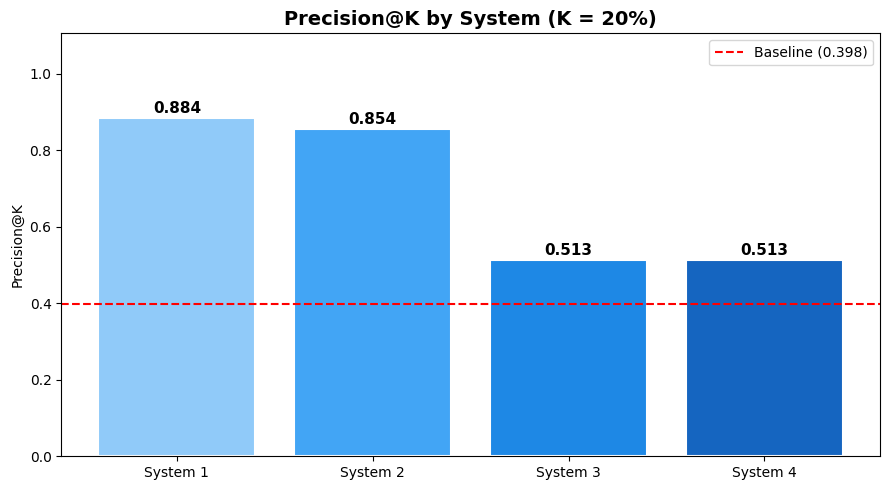

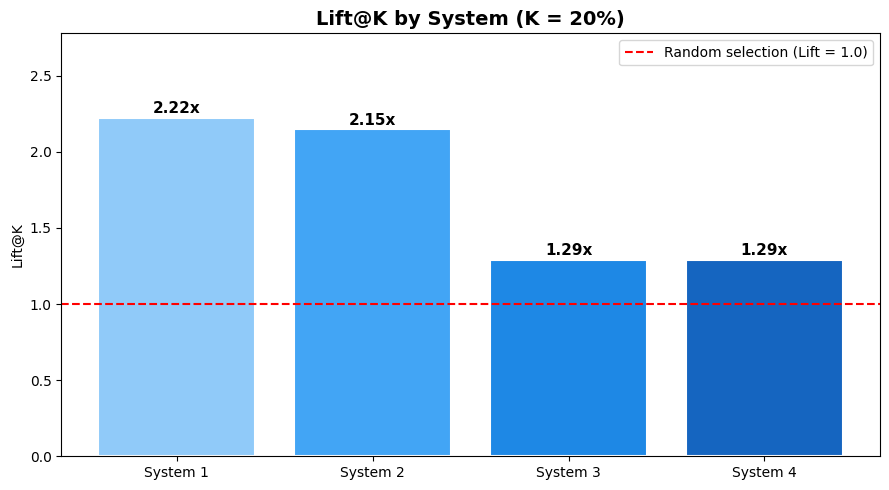

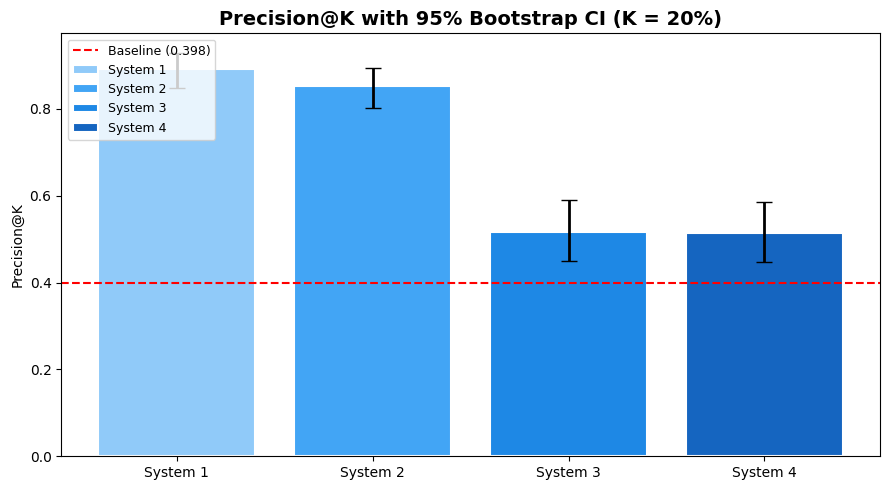

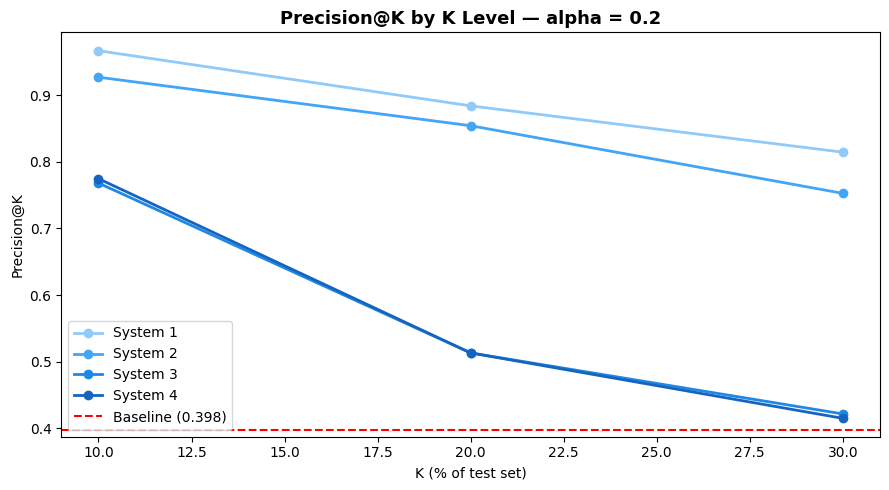

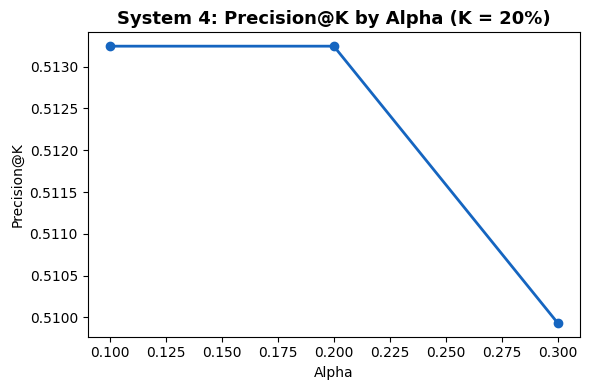

In [80]:

# =============================================================================
# CELL 14 — VISUALISATIONS
# =============================================================================

systems_order = ["System 1", "System 2", "System 3", "System 4"]
colors        = ["#90CAF9", "#42A5F5", "#1E88E5", "#1565C0"]

# --- 14a. Precision@K comparison ---
fig, ax = plt.subplots(figsize=(9, 5))
system_labels = main_results["system"].tolist()
precisions    = main_results["precision_at_k"].tolist()

bars = ax.bar(system_labels, precisions, color=colors, edgecolor="white", linewidth=1.5)
ax.axhline(
    BASELINE_CONVERSION_RATE, color="red", linestyle="--",
    label=f"Baseline ({BASELINE_CONVERSION_RATE:.3f})"
)
for bar, val in zip(bars, precisions):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
ax.set_title("Precision@K by System (K = 20%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Precision@K")
ax.set_ylim(0, max(precisions) * 1.25)
ax.legend()
plt.tight_layout()
plt.savefig("fig_08_precision_comparison.png", dpi=150)
plt.show()

# --- 14b. Lift@K comparison ---
fig, ax = plt.subplots(figsize=(9, 5))
lifts = main_results["lift_at_k"].tolist()

bars = ax.bar(system_labels, lifts, color=colors, edgecolor="white", linewidth=1.5)
ax.axhline(1.0, color="red", linestyle="--", label="Random selection (Lift = 1.0)")
for bar, val in zip(bars, lifts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.2f}x",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
ax.set_title("Lift@K by System (K = 20%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Lift@K")
ax.set_ylim(0, max(lifts) * 1.25)
ax.legend()
plt.tight_layout()
plt.savefig("fig_09_lift_comparison.png", dpi=150)
plt.show()

# --- 14c. Bootstrap CI bar chart ---
# Column names after the fix: _25pct, _500pct, _975pct
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(systems_order))

for i, sys_name in enumerate(systems_order):
    row = precision_ci[precision_ci["system"] == sys_name].iloc[0]
    mid = row["precision_at_k_500pct"]   # median
    lo  = row["precision_at_k_25pct"]    # 2.5th percentile
    hi  = row["precision_at_k_975pct"]   # 97.5th percentile

    ax.bar(i, mid, color=colors[i], edgecolor="white", linewidth=1.5, label=sys_name)
    ax.errorbar(
        i, mid,
        yerr=[[mid - lo], [hi - mid]],
        fmt="none", color="black", capsize=6, linewidth=2,
    )

ax.axhline(
    BASELINE_CONVERSION_RATE, color="red", linestyle="--",
    label=f"Baseline ({BASELINE_CONVERSION_RATE:.3f})"
)
ax.set_xticks(x_pos)
ax.set_xticklabels(systems_order)
ax.set_title("Precision@K with 95% Bootstrap CI (K = 20%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Precision@K")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("fig_10_bootstrap_ci.png", dpi=150)
plt.show()

# --- 14d. K sensitivity ---
k_sensitivity = sensitivity_results[sensitivity_results["alpha"] == 0.2].copy()

fig, ax = plt.subplots(figsize=(9, 5))
for i, sys_name in enumerate(systems_order):
    subset = k_sensitivity[k_sensitivity["system"] == sys_name]
    ax.plot(
        subset["k_fraction"].values * 100,
        subset["precision_at_k"].values,
        marker="o", label=sys_name, color=colors[i], linewidth=2,
    )
ax.axhline(
    BASELINE_CONVERSION_RATE, color="red", linestyle="--",
    label=f"Baseline ({BASELINE_CONVERSION_RATE:.3f})"
)
ax.set_xlabel("K (% of test set)")
ax.set_ylabel("Precision@K")
ax.set_title("Precision@K by K Level — alpha = 0.2", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("fig_11_k_sensitivity.png", dpi=150)
plt.show()

# --- 14e. Alpha sensitivity for System 4 ---
alpha_sensitivity = sensitivity_results[
    (sensitivity_results["system"] == "System 4") &
    (sensitivity_results["k_fraction"] == 0.2)
].copy()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    alpha_sensitivity["alpha"].values,
    alpha_sensitivity["precision_at_k"].values,
    marker="o", color="#1565C0", linewidth=2,
)
ax.set_xlabel("Alpha")
ax.set_ylabel("Precision@K")
ax.set_title("System 4: Precision@K by Alpha (K = 20%)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_12_alpha_sensitivity.png", dpi=150)
plt.show()



In [81]:

# =============================================================================
# CELL 15 — EXPORT RESULTS
# =============================================================================

model_benchmark = pd.DataFrame([
    {"model": "Logistic Regression",                         "test_auc_roc": round(logit_auc, 6)},
    {"model": "XGBoost",                                     "test_auc_roc": round(xgb_auc,   6)},
    {"model": f"Selected scoring engine: {best_model_name}", "test_auc_roc": round(best_auc,  6)},
])

print("=== TABLE 1: Model Benchmark ===")
print(model_benchmark.to_string(index=False))
model_benchmark.to_csv("table_01_model_benchmark.csv", index=False)

print("\n=== TABLE 2: Main System Comparison ===")
print(main_results.to_string(index=False))
main_results.to_csv("table_02_main_system_comparison.csv", index=False)

print("\n=== TABLE 3: Bootstrap CI (K = 20%, alpha = 0.2) ===")
print(precision_ci.to_string(index=False))
precision_ci.to_csv("table_03_bootstrap_ci.csv", index=False)

print("\n=== TABLE 4: Sensitivity Analysis — Precision@K pivot ===")
print(pivot.to_string())
sensitivity_results.to_csv("table_04_sensitivity_analysis.csv", index=False)

print("\nAll tables exported.")
print("\nFigures saved:")
for f in [
    "fig_01_class_balance.png",
    "fig_02_conv_by_last_activity.png",
    "fig_03_conv_by_lead_origin.png",
    "fig_04_conv_by_lead_source.png",
    "fig_05_conv_by_occupation.png",
    "fig_06_engagement_distributions.png",
    "fig_07_correlation_heatmap.png",
    "fig_08_precision_comparison.png",
    "fig_09_lift_comparison.png",
    "fig_10_bootstrap_ci.png",
    "fig_11_k_sensitivity.png",
    "fig_12_alpha_sensitivity.png",
]:
    print(f"  {f}")

=== TABLE 1: Model Benchmark ===
                           model  test_auc_roc
             Logistic Regression      0.857676
                         XGBoost      0.871536
Selected scoring engine: XGBoost      0.871536

=== TABLE 2: Main System Comparison ===
  system   K  k_fraction  eligible_leads  leads_selected  converters_in_K  precision_at_k  recall_at_k  lift_at_k  wasted_effort_rate
System 1 302         0.2            1511             302              267        0.884106     0.444260   2.222769            0.115894
System 2 302         0.2            1170             302              258        0.854305     0.429285   2.147844            0.145695
System 3 302         0.2            1170             302              155        0.513245     0.257903   1.290371            0.486755
System 4 302         0.2            1170             302              155        0.513245     0.257903   1.290371            0.486755

=== TABLE 3: Bootstrap CI (K = 20%, alpha = 0.2) ===
  system  prec